# Implementation of Machine Learning Models using Python

In [89]:
# TASK 1: Loading Dataset and Data Cleaning

# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Dataset
data = 'bill_authentication.csv'
df = pd.read_csv(data)

# Step 3: # Data profiling: understand the raw data before cleaning

# Display First 5 Records
print('First Five Rows:')
print(df.head())

# Display Last 5 Records
print('\nLast Five Rows:')
print(df.tail())

# Dataset Shape
print('\n Dataset Shape:', df.shape)

# Dataset Information
print('\n Dataset Information:', df.info)

# Check Datatypes
print('\n Datatypes')
print(df.dtypes)

# Check Missing Values
print('\n Missing Values:')
print(df.isnull().sum())

# Check Duplicate Records
print('\n Duplicate Rows:', df.duplicated().sum())

# Statistical Summary
display(df.describe(include = 'all'))

# Check Unique values
print("\nUnique Values")

for column in df.columns:
    print(column, ':', df[column].nunique())

First Five Rows:
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Last Five Rows:
      Variance  Skewness  Curtosis  Entropy  Class
1367   0.40614   1.34920   -1.4501 -0.55949      1
1368  -1.38870  -4.87730    6.4774  0.34179      1
1369  -3.75030 -13.45860   17.5932 -2.77710      1
1370  -3.56370  -8.38270   12.3930 -1.28230      1
1371  -2.54190  -0.65804    2.6842  1.19520      1

 Dataset Shape: (1372, 5)

 Dataset Information: <bound method DataFrame.info of       Variance  Skewness  Curtosis  Entropy  Class
0      3.62160   8.66610   -2.8073 -0.44699      0
1      4.54590   8.16740   -2.4586 -1.46210      0
2      3.86600  -2.63830    1.9242  0.10645      0
3      3.45660   9.52280   -4.0112 -3.59440      0
4      0.32924  -4.45520    4.5718 

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000



Unique Values
Variance : 1338
Skewness : 1256
Curtosis : 1270
Entropy : 1156
Class : 2


In [90]:
# Detecting Outliers Using the IQR Method
columns = ['Variance', 'Skewness','Curtosis','Entropy']

def iqr_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (data[column] < lower) | (data[column] > upper)

    return data.loc[mask, [column, 'Class']], lower, upper


for column in ['Variance', 'Skewness', 'Curtosis', 'Entropy']:

    out, lower, upper = iqr_outliers(df, column)

    print(f"\nColumn: {column}")
    print(f"Lower Fence: {round(lower, 2)}")
    print(f"Upper Fence: {round(upper, 2)}")
    print(f"Number of Outliers: {len(out)}")

    display(out)


Column: Variance
Lower Fence: -8.66
Upper Fence: 9.71
Number of Outliers: 0


,Variance,Class



Column: Skewness
Lower Fence: -14.49
Upper Fence: 19.6
Number of Outliers: 0


,Skewness,Class



Column: Curtosis
Lower Fence: -8.71
Upper Fence: 10.31
Number of Outliers: 59


,Curtosis,Class
765,15.6824,1
780,13.1779,1
815,10.7402,1
816,10.9818,1
820,17.6772,1
821,12.4547,1
826,14.9704,1
841,12.7957,1
877,10.3846,1
881,17.3087,1



Column: Entropy
Lower Fence: -6.63
Upper Fence: 4.61
Number of Outliers: 33


,Entropy,Class
41,-6.8103,0
45,-7.5034,0
47,-7.5034,0
59,-7.0495,0
139,-6.8103,0
194,-7.5836,0
202,-7.5034,0
291,-7.7853,0
341,-6.8194,0
394,-7.7581,0


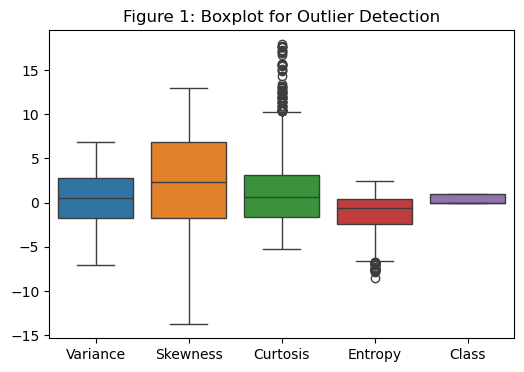

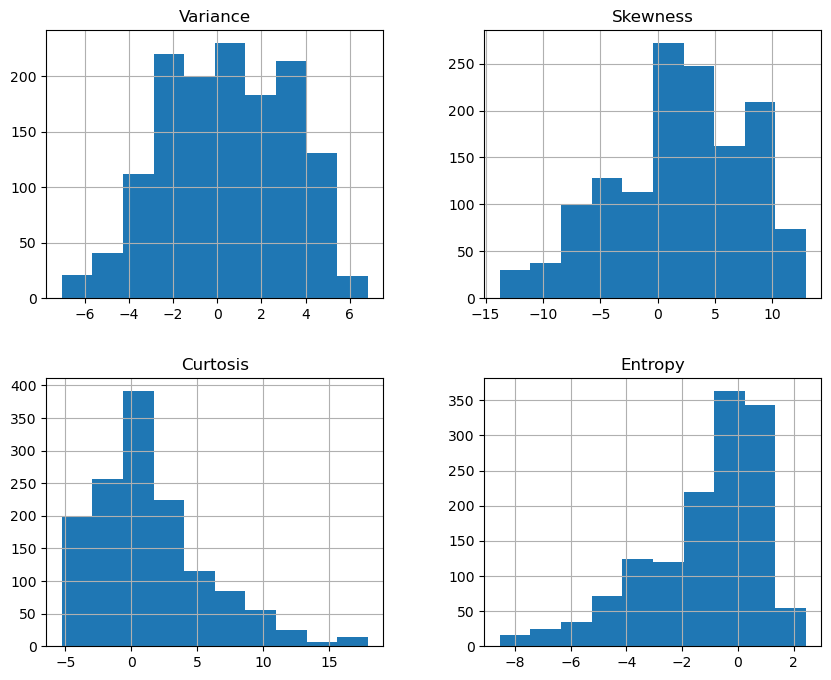

,Variance,Skewness,Curtosis,Entropy
Variance,1.000000,0.264026,-0.380850,0.276817
Skewness,0.264026,1.000000,-0.786895,-0.526321
Curtosis,-0.380850,-0.786895,1.000000,0.318841
Entropy,0.276817,-0.526321,0.318841,1.000000


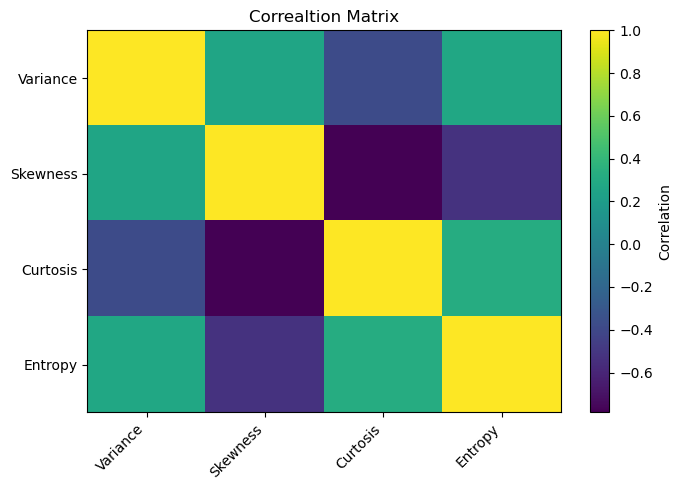

In [91]:
# Visualize outliers using boxplots
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(data=df)
plt.title("Figure 1: Boxplot for Outlier Detection")
plt.show()


# Distribution
df[["Variance", "Skewness", "Curtosis", "Entropy"]].hist(figsize = (10,8))
plt.show()

# Class Distribution
df['Class'].value_counts()

# #Pearson Correlation
print
features = ['Variance', 'Skewness', 'Curtosis', 'Entropy']
corr = df[features].corr()
display(corr)

plt.figure(figsize=(7,5))
plt.imshow(corr,aspect='auto')
plt.xticks(range(len(features)),features, rotation=45, ha = 'right')
plt.yticks(range(len(features)),features)
plt.colorbar(label='Correlation')
plt.title('Correaltion Matrix')
plt.tight_layout()
plt.show()

In [92]:
# Data cleaning

# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# Display all rows that belong to duplicate groups
duplicates = df[df.duplicated(keep=False)]
display(duplicates)

# Create a cleaned copy
clean = df.copy()

# Remove exact duplicates
clean = clean.drop_duplicates()

# Compare original and cleaned dataset
print("Original shape:", df.shape)
print("Cleaned shape:", clean.shape)

# Check remaining duplicates
print("Duplicate rows after cleaning:", clean.duplicated().sum())

Number of duplicate rows: 24


,Variance,Skewness,Curtosis,Entropy,Class
21,0.3292,-4.4552,4.5718,-0.9888,0
41,-0.2062,9.2207,-3.7044,-6.8103,0
45,-0.7869,9.5663,-3.7867,-7.5034,0
47,-0.7869,9.5663,-3.7867,-7.5034,0
107,-1.8584,7.8860,-1.6643,-1.8384,0
119,0.9297,-3.7971,4.6429,-0.2957,0
139,-0.2062,9.2207,-3.7044,-6.8103,0
145,0.5195,-3.2633,3.0895,-0.9849,0
170,0.5706,-0.0248,1.2421,-0.5621,0
190,0.9297,-3.7971,4.6429,-0.2957,0


Original shape: (1372, 5)
Cleaned shape: (1348, 5)
Duplicate rows after cleaning: 0


# TASK 2: Classification using Decision Trees


Features: ['Variance', 'Skewness', 'Curtosis', 'Entropy']
Target: Class

Training samples: 1078
Testing samples: 270

Decision Tree trained successfully.

First 10 predictions: [0 1 0 0 1 0 0 0 0 1]

First 10 actual values: [0 1 0 0 1 0 0 0 0 1]


Model Evaluation Metrics:
------------------------------
Accuracy: 97.78%



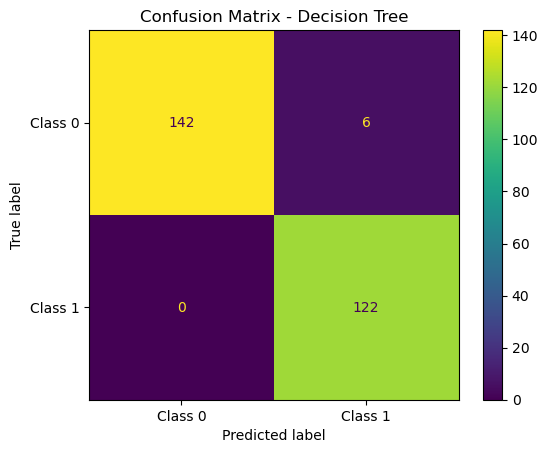


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       148
           1       0.95      1.00      0.98       122

    accuracy                           0.98       270
   macro avg       0.98      0.98      0.98       270
weighted avg       0.98      0.98      0.98       270


Feature Importance:
Variance    0.703139
Skewness    0.154694
Curtosis    0.142167
Entropy     0.000000
dtype: float64


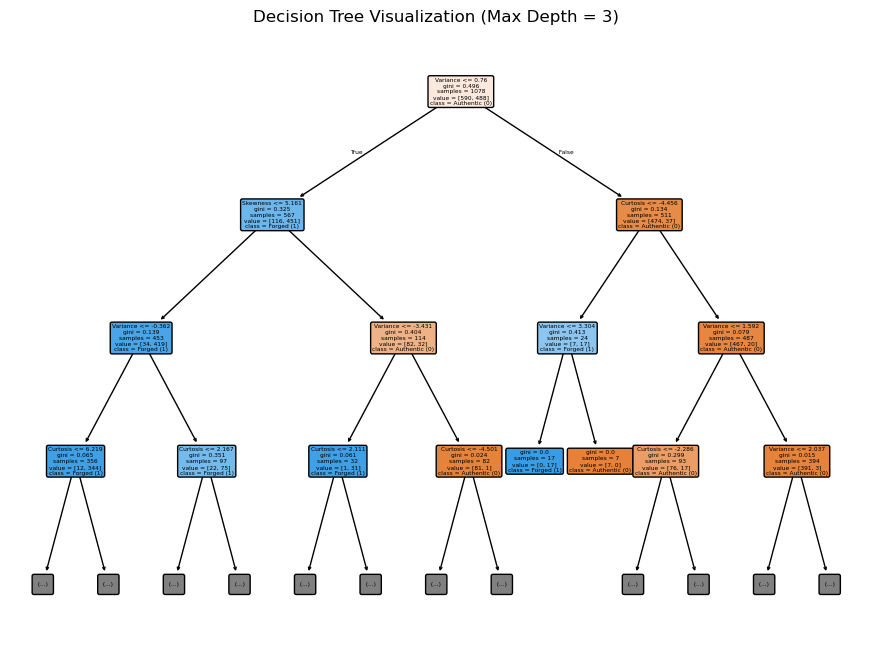

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import precision_score, recall_score, f1_score,classification_report, confusion_matrix, accuracy_score,ConfusionMatrixDisplay

# 1.  Define features (X) and target (y)
X = clean.drop('Class',axis=1)
y = clean['Class']

print("\nFeatures:", list(X.columns))
print("Target: Class")

# 2. Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size = 0.2, random_state = 42, stratify = y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# 3. Create the Decision Tree
clf = DecisionTreeClassifier(criterion ='gini',max_depth = 4, random_state = 42)

# 4. Train the Decision Tree
clf.fit(X_train, y_train)

print("\nDecision Tree trained successfully.")

# 5. Make predictions on the test data
y_pred = clf.predict(X_test)

print("\nFirst 10 predictions:", y_pred[:10] )
print("\nFirst 10 actual values:", y_test.values[:10])
print("\n")


# 6. Evaluate the Model
print("Model Evaluation Metrics:")
print("-" * 30)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

# # Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Class 0', 'Class 1'])

disp.plot(values_format='d')
plt.title("Confusion Matrix - Decision Tree")
plt.show()
print('\n', '='*70)

# Classification Report (Precision, Recall, F1-Score)
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

# 7. Feature Importance
feature_importance = pd.Series(
    clf.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


# 8. Plot the Decision Tree structure
plt.figure(figsize=(11, 8))
plot_tree(
    clf, 
    feature_names=X.columns, 
    class_names=['Authentic (0)', 'Forged (1)'], 
    filled=True, 
    rounded=True,
    max_depth=3  # Limiting depth for visual clarity
)
plt.title("Decision Tree Visualization (Max Depth = 3)")
plt.show()

# TASK 3: K-MEANS CLUSTERING

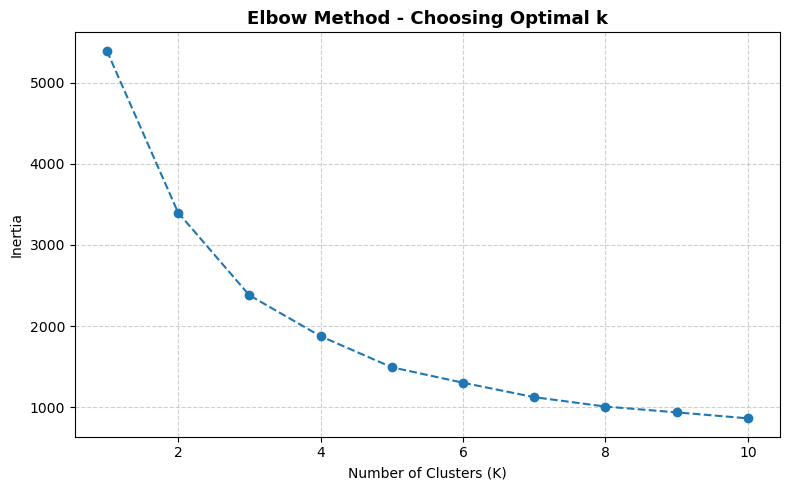

K = 2, Silhouette Score = 0.328
K = 3, Silhouette Score = 0.329
K = 4, Silhouette Score = 0.324
K = 5, Silhouette Score = 0.350
K = 6, Silhouette Score = 0.330
K = 7, Silhouette Score = 0.328
K = 8, Silhouette Score = 0.325
K = 9, Silhouette Score = 0.319
K = 10, Silhouette Score = 0.310

Cluster Counts:
Cluster
3    341
0    326
4    321
1    231
2    129
Name: count, dtype: int64


Dataset with Assigned Clusters:
   Variance  Skewness  Curtosis  Entropy  Class  Cluster
0   3.62160    8.6661   -2.8073 -0.44699      0        4
1   4.54590    8.1674   -2.4586 -1.46210      0        4
2   3.86600   -2.6383    1.9242  0.10645      0        3
3   3.45660    9.5228   -4.0112 -3.59440      0        4
4   0.32924   -4.4552    4.5718 -0.98880      0        1




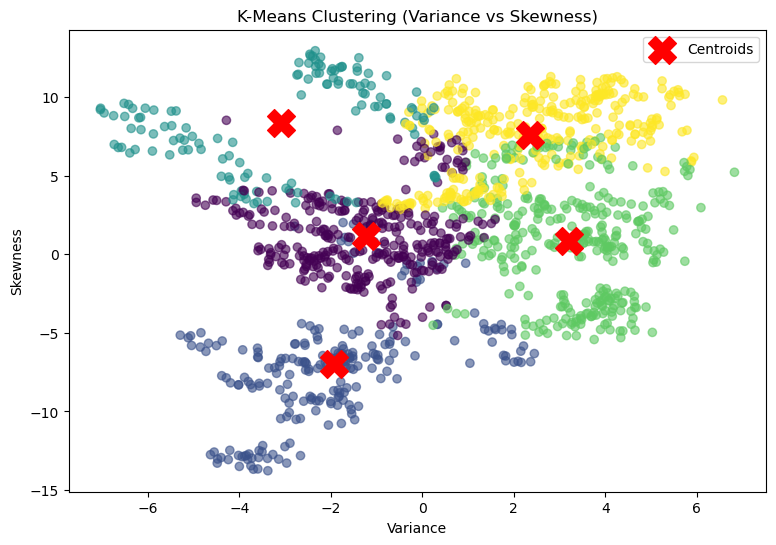

In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Select Features for Clustering
# Clustering is unsupervised, so we drop the 'Class' label

features = ['Variance', 'Skewness', 'Curtosis', 'Entropy']

X = clean[features]

# 2. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Finding the optimal number of clusters using the Elbow Method
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters = k,random_state = 42, n_init = 10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 4. Plotting the Elbow Curve
plt.figure(figsize =(8,5))
plt.plot(range(1, 11), inertia, marker='o', linestyle ='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Choosing Optimal k', fontsize=13, fontweight='bold')
plt.grid(True,linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# 5. Calculate Silhouette Score

from sklearn.metrics import silhouette_score

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, clusters)

    print(f"K = {k}, Silhouette Score = {score:.3f}")

# 6. Apply K-Means with the selected K
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 7. Add cluster labels to the dataset
clean['Cluster'] = clusters

print("\nCluster Counts:")
print(clean['Cluster'].value_counts())

# 8.Display the first few rows with their assigned clusters
print("\n")
print("Dataset with Assigned Clusters:")
print(clean.head())
print("\n" + "="*50 + "\n")

# 9. Visualize the clusters using two of the features (e.g., Variance vs Skewness)
plt.figure(figsize=(9, 6))
plt.scatter(X['Variance'], X['Skewness'], c=clean ['Cluster'], cmap='viridis', alpha=0.6)

# Convert centroids back to original scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=400,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('K-Means Clustering (Variance vs Skewness)')
plt.xlabel('Variance')
plt.ylabel('Skewness')
plt.legend()
plt.show()

# Task 4 — Evaluation of Classification Algorithm


Features: ['Variance', 'Skewness', 'Curtosis', 'Entropy']
Target: Class

Training samples: 1078
Testing samples: 270

--------------------------------------------------
CLASSIFICATION MODEL EVALUATION METRICS
--------------------------------------------------

  Accuracy  : 0.9778  (97.78%)
  Precision : 0.9531
  Recall    : 1.0000
  F1 Score  : 0.9760
  ROC-AUC   : 0.9932

--------------------------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       148
           1       0.95      1.00      0.98       122

    accuracy                           0.98       270
   macro avg       0.98      0.98      0.98       270
weighted avg       0.98      0.98      0.98       270



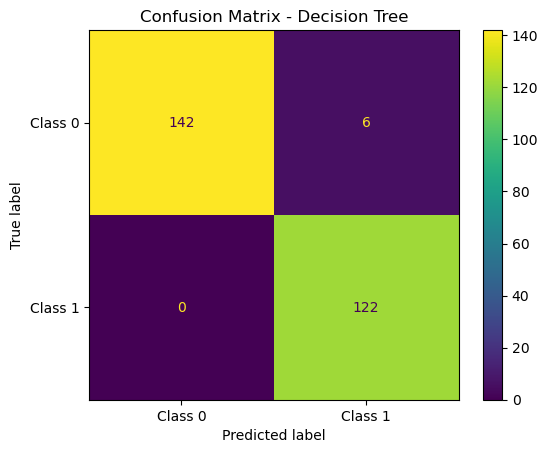


--------------------------------------------------
--------------------------------------------------
CROSS-VALIDATION RESULTS (5-Fold)
--------------------------------------------------
Scores for each fold: ['0.9741', '0.9556', '0.9667', '0.9888', '0.9703']
Mean Cross-Validation Accuracy: 0.9711 (97.11%)
Standard Deviation:             0.0108

Low standard deviation indicates consistent performance across folds.
-------------------------------------------------------


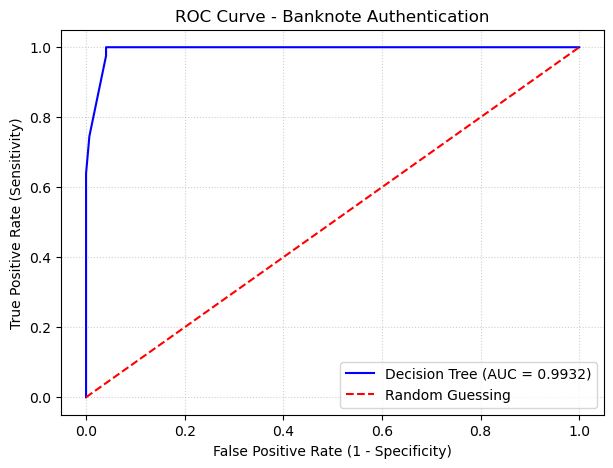

Overfitting - Train Accuracy: 100.00%
Overfitting - Test Accuracy:  99.63%
Underfitting - Train Accuracy: 85.81%
Underfitting - Test Accuracy:  83.70%


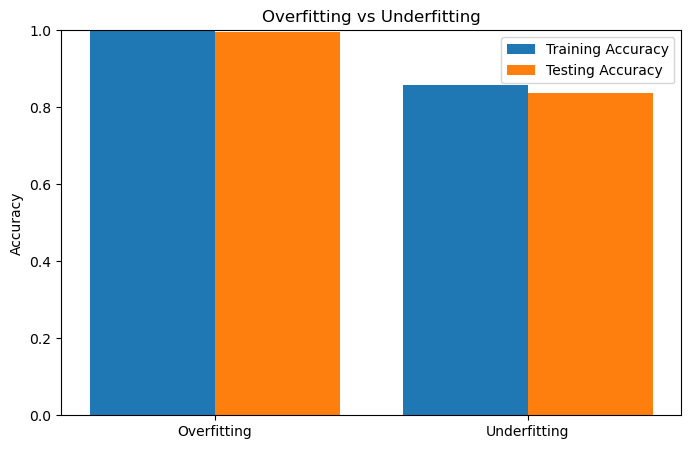

In [100]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
)

# 1. Define features and target
eatures = ['Variance', 'Skewness', 'Curtosis', 'Entropy']

X = clean[features]
y = clean['Class']

print("\nFeatures:", list(X.columns))
print("Target: Class")

# 2. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# 3. Train a classification model 
classifier = DecisionTreeClassifier(criterion='gini',max_depth=4,random_state=42)
classifier.fit(X_train, y_train)

# 4. Make Predictions
y_pred = classifier.predict(X_test)
y_pred_proba = classifier.predict_proba(X_test)[:, 1] # Probabilities for ROC-AUC

# 6. Comprehensive Evaluation Metrics
print("\n" + "-" * 50)
print("CLASSIFICATION MODEL EVALUATION METRICS")
print("-" * 50)

# (i) Core Metrics 
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print(f"\n  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")


# (ii) Full Classification Report
print("\n" + "-" * 50)
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# (iii) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])

disp.plot(values_format='d')
plt.title("Confusion Matrix - Decision Tree")
plt.show()
print("\n" + "-" * 50)

# (iv) Cross-Validation (robustness check) ───────────────────
# Tests whether performance holds across different data splits
# not just the single 80/20 split used above
cv_scores = cross_val_score(classifier, X, y, cv=5, scoring='accuracy')

print("-" * 50)
print("CROSS-VALIDATION RESULTS (5-Fold)")
print("-" * 50)
print(f"Scores for each fold: {[f'{score:.4f}' for score in cv_scores]}")
print(f"Mean Cross-Validation Accuracy: {cv_scores.mean():.4f} ({cv_scores.mean() * 100:.2f}%)")
print(f"Standard Deviation:             {cv_scores.std():.4f}")
print("\nLow standard deviation indicates consistent performance across folds.")

print("-" * 55)

# (v) Visualizing the Evaluation: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', label=f'Decision Tree (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.title('ROC Curve - Banknote Authentication')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# (vi) Overfitting Demonstration
dt_overfit = DecisionTreeClassifier(random_state=42)
dt_overfit.fit(X_train, y_train)

print(f"Overfitting - Train Accuracy: {accuracy_score(y_train, dt_overfit.predict(X_train)) * 100:.2f}%")
print(f"Overfitting - Test Accuracy:  {accuracy_score(y_test, dt_overfit.predict(X_test)) * 100:.2f}%")

# (vii) Underfitting Demonstration
dt_underfit = DecisionTreeClassifier(max_depth=1, random_state=42)
dt_underfit.fit(X_train, y_train)

print(f"Underfitting - Train Accuracy: {accuracy_score(y_train, dt_underfit.predict(X_train)) * 100:.2f}%")
print(f"Underfitting - Test Accuracy:  {accuracy_score(y_test, dt_underfit.predict(X_test)) * 100:.2f}%")

# (viii) Visualize Overfitting and Underfitting

models = ['Overfitting', 'Underfitting']

train_scores = [
    accuracy_score(y_train, dt_overfit.predict(X_train)),
    accuracy_score(y_train, dt_underfit.predict(X_train))
]

test_scores = [
    accuracy_score(y_test, dt_overfit.predict(X_test)),
    accuracy_score(y_test, dt_underfit.predict(X_test))
]

x = range(len(models))

plt.figure(figsize=(8, 5))

plt.bar(x, train_scores, width=0.4, label='Training Accuracy')
plt.bar([i + 0.4 for i in x], test_scores, width=0.4, label='Testing Accuracy')

plt.xticks([i + 0.2 for i in x], models)
plt.ylabel('Accuracy')
plt.title('Overfitting vs Underfitting')
plt.legend()
plt.ylim(0, 1)
plt.show()


# TASK 5: Evaluating a Linear Regression Algorithm


Independent Variables:
   Skewness  Curtosis  Entropy
0    8.6661   -2.8073 -0.44699
1    8.1674   -2.4586 -1.46210
2   -2.6383    1.9242  0.10645
3    9.5228   -4.0112 -3.59440
4   -4.4552    4.5718 -0.98880

Dependent Variable:
0    3.62160
1    4.54590
2    3.86600
3    3.45660
4    0.32924
Name: Variance, dtype: float64

--------------------------------------------------
LINEAR REGRESSION EVALUATION
--------------------------------------------------

Mean Absolute Error (MAE): 1.9617
Mean Squared Error (MSE): 5.6821
Root Mean Squared Error (RMSE): 2.3837
R² Score: 0.3148 31.48% variance explained)

Regression Coefficients:
    Feature  Coefficient
0  Skewness     0.152242
1  Curtosis    -0.205355
2   Entropy     0.741169

Intercept: 1.3449


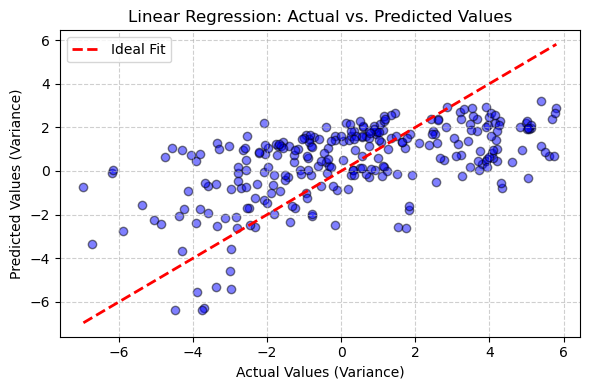

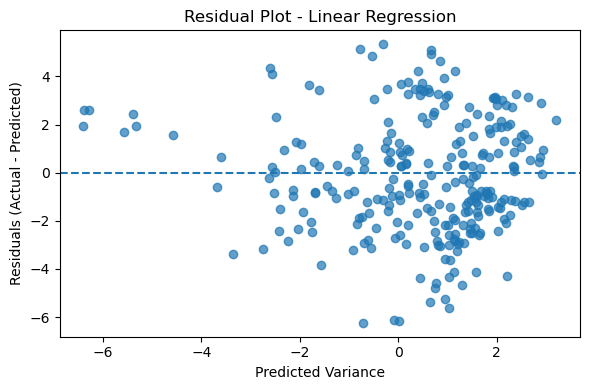

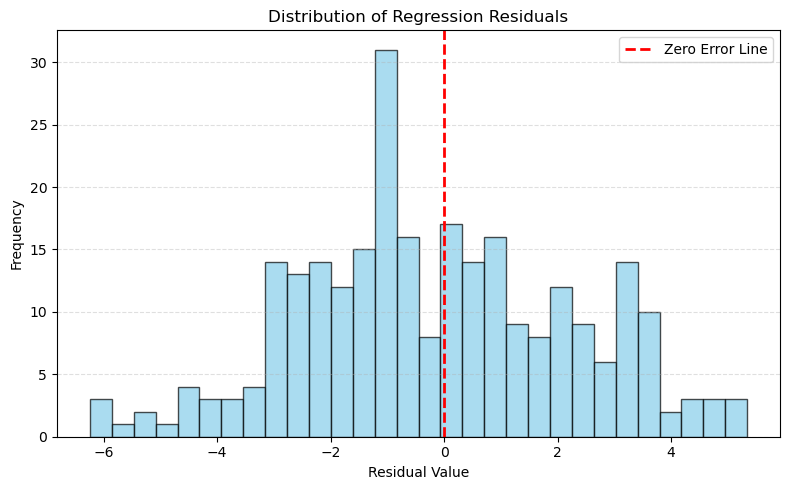


-------------------------------------------------------
5-FOLD CROSS-VALIDATION
-------------------------------------------------------

Fold-wise Results:
Fold      R²             RMSE           
----------------------------------------
1         -0.5126        2.5349         
2         -0.4184        2.3039         
3         0.2141         2.3816         
4         -1.0624        2.6467         
5         -1.4343        3.0044         

Cross-Validation Summary:
Mean R²   : -0.6427
Std R²    : 0.5664
Mean RMSE : 2.5743
Std RMSE  : 0.2458

Sample Actual vs Predicted Values:
   Actual Variance  Predicted Variance  Residual
0           0.0520              0.5050   -0.4530
1          -0.9426              1.6347   -2.5772
2          -2.8267             -2.6220   -0.2047
3          -3.8858             -5.5623    1.6765
4          -1.8046             -0.2030   -1.6016
5          -3.6085             -0.6909   -2.9176
6          -4.7462              0.6382   -5.3844
7           0.7452      

In [140]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define features and target
X = clean[['Skewness', 'Curtosis', 'Entropy']]
y = clean['Variance']

# 2. Train / Test Split 
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

print("\nIndependent Variables:")
print(X.head())

print("\nDependent Variable:")
print(y.head())

# 3. Build and Train the Model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# 4. Make Predictions on the Test Set
y_pred = reg_model.predict(X_test)

# 5. Comprehensive Regression Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n" + "-" * 50)
print("LINEAR REGRESSION EVALUATION")
print("-" * 50)

print("\nMean Absolute Error (MAE):", round(mae, 4))
print("Mean Squared Error (MSE):",round(mse, 4))
print("Root Mean Squared Error (RMSE):",round(rmse, 4))
print("R² Score:",round(r2, 4), f"{r2 * 100:.2f}% variance explained)")

# 6. Display Regression Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient":reg_model.coef_
})

print("\nRegression Coefficients:")
print(coefficients)

print("\nIntercept:",
      round(reg_model.intercept_, 4))

# # 7. Visualizing Actual vs. Predicted Values
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, edgecolors='k')
mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], color='red', linestyle='--', linewidth=2,label ='Ideal Fit')

plt.title('Linear Regression: Actual vs. Predicted Values')
plt.xlabel('Actual Values (Variance)')
plt.ylabel('Predicted Values (Variance)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 8. Residual Analysis
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred,residuals,alpha=0.7)

# Zero residual reference line

plt.axhline(y=0,linestyle="--")
plt.xlabel("Predicted Variance")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot - Linear Regression")
plt.tight_layout()
plt.show()

# 9. # Histogram: Residual Distribution
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.title("Distribution of Regression Residuals")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# 10. FIVE-FOLD CROSS-VALIDATION
cv_r2 = cross_val_score(reg_model,X,y,cv=5,scoring="r2")

cv_rmse = cross_val_score(reg_model,X,y,cv=5,scoring="neg_root_mean_squared_error")

# Convert negative RMSE scores into positive values
cv_rmse = -cv_rmse


print("\n" + "-" * 55)
print("5-FOLD CROSS-VALIDATION")
print("-" * 55)

print("\nFold-wise Results:")
print(f"{'Fold':<10}"
    f"{'R²':<15}"
    f"{'RMSE':<15}")
print("-" * 40)

for i in range(5):
    print(f"{i + 1:<10}"
        f"{cv_r2[i]:<15.4f}"
        f"{cv_rmse[i]:<15.4f}")

print("\nCross-Validation Summary:")
print(f"Mean R²   : {cv_r2.mean():.4f}")
print(f"Std R²    : {cv_r2.std():.4f}")
print(f"Mean RMSE : {cv_rmse.mean():.4f}")
print(f"Std RMSE  : {cv_rmse.std():.4f}")

# 11. ACTUAL VS PREDICTED TABLE

results = pd.DataFrame({
    "Actual Variance": y_test.values,
    "Predicted Variance": y_pred,
    "Residual": residuals.values
})
print("\nSample Actual vs Predicted Values:")
print(results.head(10).round(4))

# 12.  FINAL SUMMARY

print("\n" + "-" * 55)
print("FINAL LINEAR REGRESSION SUMMARY")
print("-" * 55)
print(f"""
Target variable  : Variance
Predictors       : Skewness, Curtosis, Entropy

Test-set performance:
MAE              : {mae:.4f}
MSE              : {mse:.4f}
RMSE             : {rmse:.4f}
R²               : {r2:.4f}

5-fold cross-validation:
Mean R²          : {cv_r2.mean():.4f}
Mean RMSE        : {cv_rmse.mean():.4f}
""")
print("Linear Regression evaluation completed successfully.")